In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Φορτώνουμε embeddings και labels
models_path = os.path.expanduser("~/igbert-embedding-analysis/results/models/")
figures_path = os.path.expanduser("~/igbert-embedding-analysis/results/figures/")

embeddings_l30 = np.load(models_path + "embeddings_l30.npy")
embeddings_l15 = np.load(models_path + "embeddings_l15.npy")
labels = pd.read_csv(models_path + "labels.csv")

print(f"Embeddings layer 30: {embeddings_l30.shape}")
print(f"Embeddings layer 15: {embeddings_l15.shape}")
print(f"Labels: {labels.shape}")

Embeddings layer 30: (4500, 1024)
Embeddings layer 15: (4500, 1024)
Labels: (4500, 2)


In [2]:
def run_linear_probe(embeddings, labels_series, label_name, layer_name):
    """
    Εκπαιδεύει logistic regression και αξιολογεί την απόδοσή του.
    """
    # Encode labels σε αριθμούς
    le = LabelEncoder()
    y = le.fit_transform(labels_series)
    
    # Train/test split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Logistic Regression
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    
    # Αξιολόγηση
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Layer: {layer_name} | Label: {label_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc*100:.1f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    return acc, y_test, y_pred, le.classes_

# Τρέχουμε για V-gene family
acc_l30_vfam, y_test_l30, y_pred_l30, classes_vfam = run_linear_probe(
    embeddings_l30, labels['v_family'], "V-gene Family", "Layer 30"
)

acc_l15_vfam, _, _, _ = run_linear_probe(
    embeddings_l15, labels['v_family'], "V-gene Family", "Layer 15"
)


Layer: Layer 30 | Label: V-gene Family
Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

       IGHV1       1.00      1.00      1.00       300
       IGHV3       1.00      1.00      1.00       300
       IGHV4       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Layer: Layer 15 | Label: V-gene Family
Accuracy: 99.9%

Classification Report:
              precision    recall  f1-score   support

       IGHV1       1.00      1.00      1.00       300
       IGHV3       1.00      1.00      1.00       300
       IGHV4       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [3]:
# Τρέχουμε για isotype
acc_l30_iso, y_test_iso_l30, y_pred_iso_l30, classes_iso = run_linear_probe(
    embeddings_l30, labels['isotype'], "Isotype", "Layer 30"
)

acc_l15_iso, _, _, _ = run_linear_probe(
    embeddings_l15, labels['isotype'], "Isotype", "Layer 15"
)


Layer: Layer 30 | Label: Isotype
Accuracy: 70.6%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.69      0.67      0.68       300
        IGHG       0.71      0.73      0.72       300
        IGHM       0.72      0.72      0.72       300

    accuracy                           0.71       900
   macro avg       0.71      0.71      0.71       900
weighted avg       0.71      0.71      0.71       900


Layer: Layer 15 | Label: Isotype
Accuracy: 75.0%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.74      0.68      0.71       300
        IGHG       0.77      0.79      0.78       300
        IGHM       0.74      0.78      0.76       300

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.75      0.75      0.75       900




Layer: Layer 15 | Label: Isotype
Accuracy: 75.0%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.74      0.68      0.71       300
        IGHG       0.77      0.79      0.78       300
        IGHM       0.74      0.78      0.76       300

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.75      0.75      0.75       900



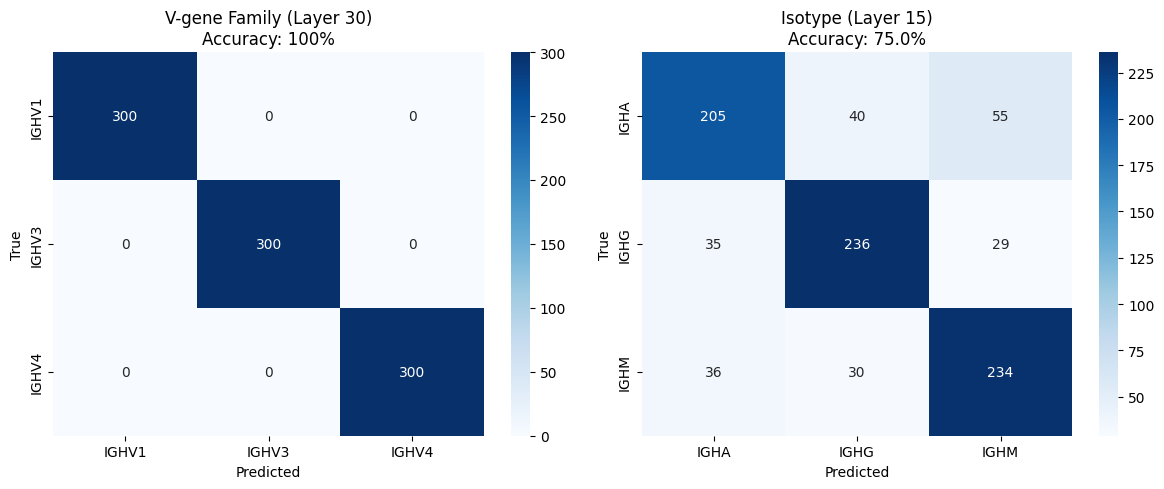

Αποθηκεύτηκε: confusion_matrices.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix για V-gene (layer 30)
cm_vfam = confusion_matrix(y_test_l30, y_pred_l30)
sns.heatmap(cm_vfam, annot=True, fmt='d', ax=axes[0],
            xticklabels=classes_vfam, yticklabels=classes_vfam,
            cmap='Blues')
axes[0].set_title(f"V-gene Family (Layer 30)\nAccuracy: 100%")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")

# Confusion matrix για isotype (layer 15, το καλύτερο)
acc_l15_iso_rerun, y_test_iso, y_pred_iso, classes_iso = run_linear_probe(
    embeddings_l15, labels['isotype'], "Isotype", "Layer 15"
)
cm_iso = confusion_matrix(y_test_iso, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', ax=axes[1],
            xticklabels=classes_iso, yticklabels=classes_iso,
            cmap='Blues')
axes[1].set_title(f"Isotype (Layer 15)\nAccuracy: 75.0%")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(figures_path + "confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: confusion_matrices.png")